<a href="https://colab.research.google.com/github/StarmapC/bangla-english-nlp-study/blob/main/1st_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import skew

# 1. Load Data
file_path = '/content/dataset_zidan-research_2026-02-15_10-06-48-661 (3).json'
df_research = pd.read_json(file_path, convert_dates=False)

# 2. Identify and Sum Available Engagement Metrics
# This method searches for 'likes', 'shares', and 'comments' regardless of exact naming
cols = df_research.columns
l_col = [c for c in cols if 'like' in c.lower()]
s_col = [c for c in cols if 'share' in c.lower()]
c_col = [c for c in cols if 'comment' in c.lower()]

# Create the Raw Total Engagement column safely
df_research['raw_total_eng'] = (
    df_research[l_col[0]].fillna(0) if l_col else 0
) + (
    df_research[s_col[0]].fillna(0) if s_col else 0
) + (
    df_research[c_col[0]].fillna(0) if c_col else 0
)

# 3. Statistical Baseline
raw_skewness = skew(df_research['raw_total_eng'])

print(f"Data successfully initialized. Total Observations (N): {len(df_research)}")
print(f"Detected Columns: {list(cols)}")
print(f"Empirical Baseline Skewness: {raw_skewness:.4f}")

Data successfully initialized. Total Observations (N): 713
Detected Columns: ['facebookUrl', 'postId', 'pageName', 'url', 'time', 'timestamp', 'user', 'collaborators', 'text', 'textReferences', 'link', 'likes', 'shares', 'topReactionsCount', 'media', 'feedbackId', 'reactionLikeCount', 'reactionLoveCount', 'reactionCareCount', 'topLevelUrl', 'facebookId', 'pageAdLibrary', 'inputUrl', 'reactionHahaCount', 'comments', 'reactionWowCount', 'isVideo', 'viewsCount', 'reactionAngryCount', 'reactionSadCount', 'sharedPost', 'actionLink', 'previewTitle', 'previewDescription', 'previewSource', 'previewTarget', 'timeCreated', 'timestampCreated']
Empirical Baseline Skewness: 11.5405


In [ ]:
# Install missing dependency
!pip install emoji --quiet

import pandas as pd
import numpy as np
import re
import string
import emoji
import nltk
from scipy.stats import skew, kurtosis
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 1. INITIALIZATION & STOPWORD EXPANSION
nltk.download(['stopwords', 'wordnet', 'omw-1.4', 'punkt'], quiet=True)
en_stops = set(stopwords.words('english')).union({
    "the", "is", "at", "on", "and", "for", "with", "from", "this", "that", "it", "to", "in",
    "of", "by", "are", "be", "was", "will", "can", "if", "or", "but"
})
bn_stops = {"এবং", "ও", "হয়", "করে", "এই", "সেই", "জন্য", "থেকে", "পর", "সাথে", "করা", "ছিল", "হবে"}
all_stops = en_stops.union(bn_stops)
lemmatizer = WordNetLemmatizer()

# 2. DATA LOADING & CLEANING
file_path = '/content/dataset_zidan-research_2026-02-15_10-06-48-661 (3).json'
df = pd.read_json(file_path, convert_dates=False)
df = df.dropna(subset=['text']).copy()
df = df[df['text'].str.strip() != ""].copy()

# 3. CONTROL VARIABLE EXTRACTION
df['is_sponsored'] = df['pageAdLibrary'].notnull().astype(int)
df['hashtag_count'] = df['text'].str.count('#').fillna(0)
df['is_video'] = df['media'].apply(lambda x: 1 if isinstance(x, list) and len(x) > 0 and 'Video' in str(x[0]) else 0)
df['media_type'] = df['media'].apply(lambda x: x[0].get('__typename', 'TextOnly') if isinstance(x, list) and len(x) > 0 else 'TextOnly')

# 4. PRE-PROCESSING FUNCTION
def master_nlp_clean(text):
    if not text: return None
    text = text.lower()
    text = emoji.demojize(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    # Standardize Business Terms (3)
    text = text.replace("corp", "corporation").replace("ltd", "limited").replace("mgt", "management")
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in all_stops]
    return " ".join(tokens)

df['processed_text'] = df['text'].apply(master_nlp_clean)
df = df.dropna(subset=['processed_text']).copy()

# 5. VIRAL OUTLIER CONTROL & DATA NORMALIZATION
df['raw_eng'] = df['likes'].fillna(0) + df['shares'].fillna(0) + df['comments'].fillna(0)
df = df[df['raw_eng'] <= (df['raw_eng'].median() * 10)].copy() # Remove 10x outliers
s_before, k_before = skew(df['raw_eng']), kurtosis(df['raw_eng'])
df['log_eng'] = np.log1p(df['raw_eng'])
s_after, k_after = skew(df['log_eng']), kurtosis(df['log_eng'])
df['rel_engagement'] = df['log_eng'] / df['log_eng'].mean()


# Calculate the 'Age' of each post
df['timestamp'] = pd.to_datetime(df['timestamp'])
reference_date = df['timestamp'].max()
df['post_age_days'] = (reference_date - df['timestamp']).dt.days.replace(0, 1)

# Create the "Time-Corrected" Engagement Score
df['log_eng_timed'] = df['log_eng'] / np.log1p(df['post_age_days'])

# Update Relative Engagement based on this new fair score
df['rel_engagement'] = df['log_eng_timed'] / df['log_eng_timed'].mean()

# 6. CODE SWITCHING & NUMERICAL LEVELS
def cs_metrics(text):
    tokens = text.split()
    bn = len([w for w in tokens if re.search(r'[\u0980-\u09FF]', w)])
    en = len([w for w in tokens if re.search(r'[a-zA-Z]', w)])
    total = len(tokens)
    ratio = min(bn, en) / total if total > 0 else 0
    if bn > 0 and en == 0: cat = "Pure Bangla"
    elif en > 0 and bn == 0: cat = "Pure English"
    else: cat = "High CS" if ratio > 0.15 else "Low CS"
    return pd.Series([cat, ratio])

df[['cs_cat_label', 'cs_level']] = df['processed_text'].apply(cs_metrics)

# 7. RANDOMIZATION & INDEPENDENCE
df = df.sample(frac=1).reset_index(drop=True)

print(f"Current N={len(df)}")
print(f"Skewness: Before={s_before:.4f}, After={s_after:.4f}")
print(f"Kurtosis: Before={k_before:.4f}, After={k_after:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 12.5 MB/s eta 0:00:00
Current N=617
Skewness: Before=1.9237, After=-0.3393
Kurtosis: Before=3.2331, After=-0.7359


In [ ]:
!pip install transformers tqdm bertopic emoji --quiet

import pandas as pd
import numpy as np
from transformers import pipeline
from tqdm import tqdm
from bertopic import BERTopic

# 1. MODEL INITIALIZATION
# Selection of multilingual DistilBERT for sentiment and specialized emotion classifier
sent_pipe = pipeline("sentiment-analysis", model="lxyuan/distilbert-base-multilingual-cased-sentiments-student", truncation=True)
emot_pipe = pipeline("text-classification", model="michellejieli/emotion_text_classifier", truncation=True)

# 2. NUMERIC MAPPING OF LINGUISTIC CATEGORIES
cs_map = {
    'Pure Bangla': 1,
    'Pure English': 2,
    'Low CS': 3,
    'High CS': 4 # All code-switching > 0.15 is now High CS
}
# Ensure alignment with the labels generated in Phase 1
df['cs_numeric'] = df['cs_cat_label'].map(cs_map).fillna(0).astype(int)

# 3. SENTIMENT AND EMOTION EXTRACTION
def get_nlp_scores(text):
    if not text or len(str(text)) < 3:
        return "Neutral", 0.0, "Neutral", 0.0
    try:
        s_res = sent_pipe(str(text))[0]
        e_res = emot_pipe(str(text))[0]
        return s_res['label'], s_res['score'], e_res['label'], e_res['score']
    except Exception:
        return "Neutral", 0.0, "Neutral", 0.0

print("Commencing Sentiment and Emotion Score Calculation...")
tqdm.pandas()
nlp_results = df['text'].progress_apply(lambda x: pd.Series(get_nlp_scores(x)))
df[['sentiment', 'sentiment_score', 'emotion', 'emotion_score']] = nlp_results

# 4. TOPIC MODELING (BERTopic)
# Probability calculation enabled to measure membership strength per post
topic_model = BERTopic(language="multilingual", calculate_probabilities=True)
topics, probs = topic_model.fit_transform(df['processed_text'])

df['topic_id'] = topics
# Calculation of topic confidence score; assigned 0 for noise (-1)
df['topic_score'] = [np.max(p) if topics[i] != -1 else 0 for i, p in enumerate(probs)]

# 5. FINAL TABLE GENERATION AND STANDARDIZATION
id_col = next((col for col in ['facebookUrl', 'postId', 'url'] if col in df.columns), 'index')

mapping = {
    id_col: 'Post ID',
    'text': 'Post Text',
    'cs_numeric': 'Code Switching Level (1-4)',
    'log_eng_timed': 'Relative Engagement (Time-Normalized)',
    'topic_id': 'Topic ID',
    'topic_score': 'Topic Confidence Score',
    'sentiment': 'Sentiment Analysis',
    'sentiment_score': 'Sentiment Probability',
    'emotion': 'Emotion Detection',
    'emotion_score': 'Emotion Probability'
}

final_cols = [k for k in mapping.keys() if k in df.columns]
final_table = df[final_cols].copy().rename(columns=mapping)

# Corrected Topic Labeling
topic_labels = topic_model.generate_topic_labels(nr_words=3, separator=", ")
final_table['Topic Keywords'] = final_table['Topic ID'].apply(lambda x: topic_labels[x] if x != -1 else "Noise")

# 6. EXPORT AND VERIFICATION
print(f"Dataset Processing Complete. N={len(final_table)}")
final_table.to_excel("Final_Research_Data_Standardized.xlsx", index=False)
final_table.head(10)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: michellejieli/emotion_text_classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Commencing Sentiment and Emotion Score Calculation...


100%|██████████| 617/617 [07:13<00:00,  1.42it/s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dataset Processing Complete. N=617


,Post ID,Post Text,Code Switching Level (1-4),Relative Engagement (Time-Normalized),Topic ID,Topic Confidence Score,Sentiment Analysis,Sentiment Probability,Emotion Detection,Emotion Probability,Topic Keywords
0,https://www.facebook.com/star.tech.ltd,২ হাজার টাকা বাজেটের আশেপাশে যদি Smart Watch ন...,4,4.087463,-1,0.000000,positive,0.430817,neutral,0.458061,Noise
1,https://www.facebook.com/BashundharaHousingbd,An investment that grows stronger with every p...,2,9.942515,2,0.925804,positive,0.866139,joy,0.548682,"1, checkmark, smallbluediamond, price"
2,https://www.facebook.com/SquarePharmaLtd,Pain-Free Moments Matter!\nSay goodbye to cram...,2,11.394999,2,0.656783,positive,0.899122,joy,0.516954,"1, checkmark, smallbluediamond, price"
3,https://www.facebook.com/star.tech.ltd,Philips 3000 Series 6.2L Air Fryer 🍟✨\nCook he...,2,4.000000,1,1.000000,positive,0.853257,joy,0.720598,"0, পর, কর, আর"
4,https://www.facebook.com/bkashlimited,"এখন আপনার জন্য প্রতিদিন অফার থাকছে ""মাই অফারস""...",1,8.588715,0,0.846277,negative,0.524898,neutral,0.889460,"-1, bestdeal, compare, comparison"
5,https://www.facebook.com/10minuteschool,ইংরেজির দুনিয়ায় এক লাফে এগিয়ে যাও নতুন উচ্চ...,3,7.870365,0,1.000000,positive,0.628009,neutral,0.595446,"-1, bestdeal, compare, comparison"
6,https://www.facebook.com/bkashlimited,🍛 দেশীয় খাবার এনজয় করার মোমেন্টটাই অন্যরকম!\n🍽...,3,7.087463,0,0.764945,positive,0.485758,neutral,0.782597,"-1, bestdeal, compare, comparison"
7,https://www.facebook.com/BashundharaHousingbd,"At Bashundhara Housing, A to P blocks are full...",2,11.266201,2,0.960282,positive,0.617632,neutral,0.376747,"1, checkmark, smallbluediamond, price"
8,https://www.facebook.com/BashundharaHousingbd,"Celebrating the spirit of love, peace, and tog...",2,5.247928,2,0.522207,positive,0.976515,joy,0.982175,"1, checkmark, smallbluediamond, price"
9,https://www.facebook.com/10minuteschool,কৃতী শিক্ষার্থী সংবর্ধনা SSC 2025 এ তোমাদের প্...,3,8.535275,0,0.807547,negative,0.421209,neutral,0.776703,"-1, bestdeal, compare, comparison"


In [ ]:
import pandas as pd
import numpy as np

# SAFETY CHECK: Sync df_controlled with the latest NLP results from df
if 'df' in locals():
    print("Syncing latest NLP results to df_controlled...")
    df_controlled = df.copy()
elif 'df_controlled' not in locals():
    raise NameError("Dataframe not found. Please run the NLP processing cell first!")

# 1. Ensure the engagement velocity column exists
if 'log_eng_final' not in df_controlled.columns:
    # Fallback to log_eng_timed if that was the name used in the NLP cell
    source_col = 'log_eng_timed' if 'log_eng_timed' in df_controlled.columns else 'log_eng'
    df_controlled['log_eng_final'] = df_controlled[source_col] / np.log1p(df_controlled.get('post_age_days', 1))

# 2. Define the exact professional mapping requested
thesis_mapping = {
    'post_id': 'Post ID',
    'text': 'Post Text',
    'processed_text': 'NLP Process Text',
    'cs_numeric': 'Code Switching Level (1-4)',
    'log_eng_timed': 'Relative Engagement (Time-Normalized)',
    'topic_id': 'Topic ID',
    'topic_score': 'Topic Confidence Score',
    'sentiment': 'Sentiment Analysis',
    'sentiment_score': 'Sentiment Probability',
    'emotion': 'Emotion Detection',
    'emotion_score': 'Emotion Probability'
}

# 3. Select and Rename
final_cols = [k for k in thesis_mapping.keys() if k in df.columns]
final_table = df[final_cols].copy().rename(columns=thesis_mapping)

# 4. Display and Export
print(f"✅ Final Table Created with {len(final_table.columns)} Columns (N={len(final_table)})")
pd.set_option('display.max_columns', None)
display(final_table.head(10))

# Save the master table
final_table.to_excel("Master_Research_Final_Table.xlsx", index=False)

Syncing latest NLP results to df_controlled...
✅ Final Table Created with 10 Columns (N=617)


,Post Text,NLP Process Text,Code Switching Level (1-4),Relative Engagement (Time-Normalized),Topic ID,Topic Confidence Score,Sentiment Analysis,Sentiment Probability,Emotion Detection,Emotion Probability
0,"২ হাজার টাকা বাজেটের আশেপাশে যদি Smart Watch নিতে চান,তাহলে আপনার পছন্দ কোনটি ?\n\n📌 Detailed Comparison -\nhttps://www.startech.com.bd/common/com...",হাজার টাকা বাজেটের আশেপাশে যদি smart watch নিতে চানতাহলে আপনার পছন্দ কোনটি pushpin detailed comparison compare bestdeal startech,4,4.087463,-1,0.000000,positive,0.430817,neutral,0.458061
1,"An investment that grows stronger with every promise fulfilled — from wide, well-planned roads that ensure seamless connectivity, to lush green pa...",investment grows stronger every promise fulfilled — wide wellplanned road ensure seamless connectivity lush green park breathe life day worldclass...,2,9.942515,2,0.925804,positive,0.866139,joy,0.548682
2,Pain-Free Moments Matter!\nSay goodbye to cramps and hello to comfort.\n\n💃 Move freely\n🌸 Live confidently\n😊 Feel unstoppable\n\n#NorvisPainFree...,painfree moment matter say goodbye cramp hello comfort womandancing move freely cherryblossom live confidently smilingfacewithsmilingeyes feel uns...,2,11.394999,2,0.656783,positive,0.899122,joy,0.516954
3,Philips 3000 Series 6.2L Air Fryer 🍟✨\nCook healthier and tastier meals with rapid air technology and easy-to-use controls — perfect for everyday ...,philip series l air fryer frenchfriessparkles cook healthier tastier meal rapid air technology easytouse control — perfect everyday frying baking ...,2,4.000000,1,1.000000,positive,0.853257,joy,0.720598
4,"এখন আপনার জন্য প্রতিদিন অফার থাকছে ""মাই অফারস""-এ। \nক্যাশব্যাক হোক বা রিওয়ার্ড পয়েন্টস, কিছু না কিছু পাবেন সবসময়।\n\nমাই অফারস চেক করতে:\n- বিকাশ ...",এখন আপনার প্রতিদিন অফার থাকছে মাই অফারসএ। ক্যাশব্যাক হোক বা রিওয়ার্ড পয়েন্টস কিছু না কিছু পাবেন সবসময়। মাই অফারস চেক করতে বিকাশ অ্যাপে লগইন করুন হ...,1,8.588715,0,0.846277,negative,0.524898,neutral,0.889460
5,ইংরেজির দুনিয়ায় এক লাফে এগিয়ে যাও নতুন উচ্চতায়! 🚀,ইংরেজির দুনিয়ায় এক লাফে এগিয়ে যাও নতুন উচ্চতায় rocket,3,7.870365,0,1.000000,positive,0.628009,neutral,0.595446
6,"🍛 দেশীয় খাবার এনজয় করার মোমেন্টটাই অন্যরকম!\n🍽️ তাই বিকাশ পেমেন্টে Cookups-এ পাচ্ছেন,\n• ‘bKashCU3’ কোড দিয়ে ন্যূনতম ৳৫৯৯ পেমেন্টে ৩%, ডিসকাউন্ট।\...",curryrice দেশীয় খাবার এনজয় করার মোমেন্টটাই অন্যরকম forkandknifewithplate তাই বিকাশ পেমেন্টে cookupsএ পাচ্ছেন • ‘bkashcu’ কোড দিয়ে ন্যূনতম ৳ পেমেন্...,3,7.087463,0,0.764945,positive,0.485758,neutral,0.782597
7,"At Bashundhara Housing, A to P blocks are fully sold out, and only a limited number of ready plots remain. This is your final window to secure you...",bashundhara housing p block fully sold limited number ready plot remain final window secure part growing community readyplot limitedplots growingc...,2,11.266201,2,0.960282,positive,0.617632,neutral,0.376747
8,"Celebrating the spirit of love, peace, and togetherness this Janmashtami. May Lord Krishna bless your home with harmony and happiness.\n\n#HappyJa...",celebrating spirit love peace togetherness janmashtami may lord krishna bless home harmony happiness happyjanmashtami bashundharahousing bashundha...,2,5.247928,2,0.522207,positive,0.976515,joy,0.982175
9,কৃতী শিক্ষার্থী সংবর্ধনা SSC 2025 এ তোমাদের প্রিয় টিচাররা তোমাদের সাথে খেলেছিল এই মজার গেইমটা! \n\nএবছর নতুন কী গেইম খেলা যায়? কমেন্টে জানাও তো। 🙌,কৃতী শিক্ষার্থী সংবর্ধনা ssc এ তোমাদের প্রিয় টিচাররা তোমাদের খেলেছিল মজার গেইমটা এবছর নতুন কী গেইম খেলা যায় কমেন্টে জানাও তো। raisinghands,3,8.535275,0,0.807547,negative,0.421209,neutral,0.776703


In [ ]:
# --- STEP 1: ADD CONTROLS TO EXISTING final_table ---

# 1. Create Media Format (Video, Photo, or Text)
def get_media_format(row):
    # We pull from 'df' because it has the raw 'isVideo' and 'media' columns
    if row.get('isVideo') == True: return 'Video'
    if isinstance(row.get('media'), list) and len(row.get('media')) > 0: return 'Photo'
    return 'Text'

# 2. Identify if the post was a Shared post
def get_is_shared(row):
    return 1 if pd.notnull(row.get('sharedPost')) else 0

# 3. Apply these to final_table
# We use the index to make sure the rows match perfectly
final_table['Media_Format'] = df.apply(get_media_format, axis=1)
final_table['Is_Shared'] = df.apply(get_is_shared, axis=1)

# Verify the new columns are there
print("New Control Columns Added:")
print(final_table[['Media_Format', 'Is_Shared']].head())

New Control Columns Added:
  Media_Format  Is_Shared
0        Photo          0
1        Video          0
2        Video          0
3        Photo          0
4        Video          0


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. PEARSON CORRELATION (Including Controls)
# Only numeric columns can be used here
corr_cols = ['Code Switching Level (1-4)', 'Sentiment Probability',
             'Emotion Probability', 'Is_Shared', 'Relative Engagement (Time-Normalized)']

print("--- 1. PEARSON CORRELATION MATRIX ---")
print(final_table[corr_cols].corr()['Relative Engagement (Time-Normalized)'].sort_values(ascending=False))

# 2. MULTIVARIATE OLS REGRESSION
# Adding Media_Format and Is_Shared as independent controls
reg_formula = """
Q("Relative Engagement (Time-Normalized)") ~
Q("Code Switching Level (1-4)") +
Q("Sentiment Probability") +
Q("Emotion Probability") +
C(Media_Format) +
Is_Shared +
C(Q("Topic ID"))
"""
model_ols = ols(reg_formula, data=final_table).fit()
print("\n--- 2. MULTIVARIATE OLS REGRESSION SUMMARY (WITH CONTROLS) ---")
print(model_ols.summary())

# 3. ANCOVA (Partitioning Variance with Controls)
ancova_formula = """
Q("Relative Engagement (Time-Normalized)") ~
C(Q("Code Switching Level (1-4)")) +
C(Q("Topic ID")) +
C(Media_Format) +
Is_Shared
"""
model_ancova = ols(ancova_formula, data=final_table).fit()
aov_table = sm.stats.anova_lm(model_ancova, typ=2)

# Effect Size (Eta-Squared)
aov_table['eta_sq'] = aov_table['sum_sq'] / sum(aov_table['sum_sq'])
print("\n--- 3. ANCOVA TABLE WITH EFFECT SIZE ---")
print(aov_table)

# 4. TUKEY HSD FOR TOPICS
# Updated to use final_table column names
posthoc_topics = pairwise_tukeyhsd(endog=final_table['Relative Engagement (Time-Normalized)'],
                                 groups=final_table['Topic ID'].astype(str),
                                 alpha=0.05)
print("\n--- 4. TUKEY HSD POST-HOC TEST (TOPIC COMPARISON) ---")
print(posthoc_topics.summary())

# 5. TOPIC RANKING
topic_ranking = final_table.groupby('Topic ID')['Relative Engagement (Time-Normalized)'].mean().sort_values(ascending=False)
print("\n--- 5. FINAL TOPIC RANKING (Mean Engagement Velocity) ---")
print(topic_ranking)

--- 1. PEARSON CORRELATION MATRIX ---
Relative Engagement (Time-Normalized)    1.000000
Emotion Probability                      0.086648
Code Switching Level (1-4)               0.067532
Is_Shared                               -0.030654
Sentiment Probability                   -0.280106
Name: Relative Engagement (Time-Normalized), dtype: float64

--- 2. MULTIVARIATE OLS REGRESSION SUMMARY (WITH CONTROLS) ---
                                        OLS Regression Results                                        
Dep. Variable:     Q("Relative Engagement (Time-Normalized)")   R-squared:                       0.519
Model:                                                    OLS   Adj. R-squared:                  0.509
Method:                                         Least Squares   F-statistic:                     50.14
Date:                                        Sun, 08 Mar 2026   Prob (F-statistic):           4.84e-87
Time:                                                13:12:42   Log-Likel

--- STATISTICAL COMPARISON OF CS GROUPS ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -1.7687    0.0 -2.7195  -0.818   True
     1      3  -1.3181 0.0019 -2.2595 -0.3767   True
     1      4  -0.7853   0.15 -1.7427  0.1721  False
     2      3   0.4506 0.1458 -0.0953  0.9965  False
     2      4   0.9834 0.0001  0.4103  1.5565   True
     3      4   0.5328 0.0669 -0.0246  1.0901  False
----------------------------------------------------

--- FINAL PERFORMANCE RANKING (N=617) ---
                                mean       std  count
Code Switching Level (1-4)                           
1                           8.906512  1.743689     40
2                           7.137769  2.475713    189
3                           7.588412  2.096256    213
4                           8.121179  1.784655    175


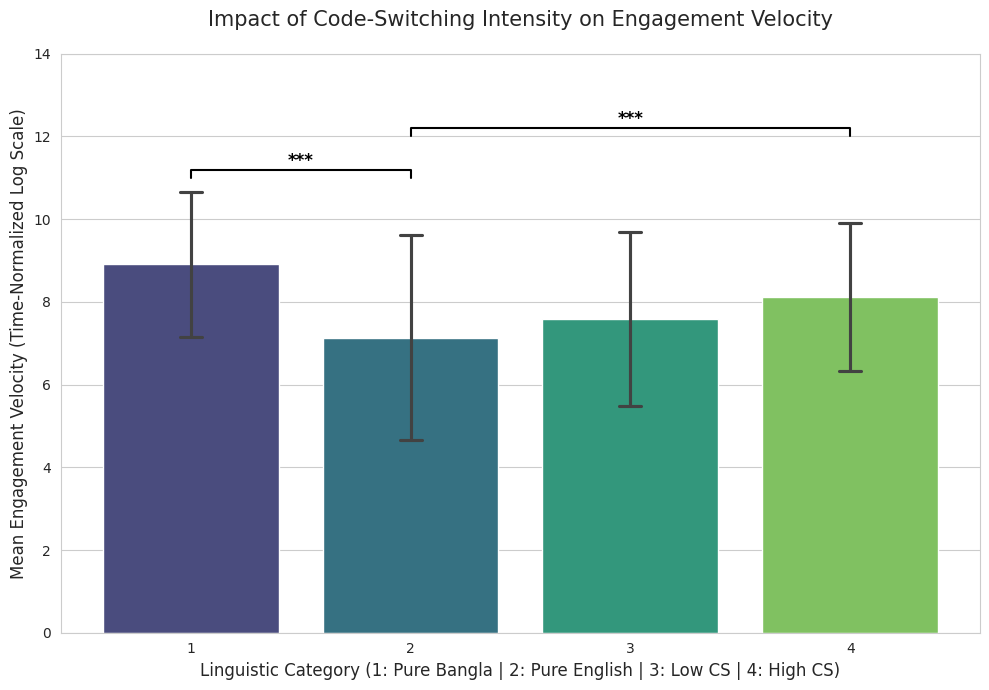

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. RUN TUKEY HSD
posthoc_cs = pairwise_tukeyhsd(endog=final_table['Relative Engagement (Time-Normalized)'],
                               groups=final_table['Code Switching Level (1-4)'].astype(str),
                               alpha=0.05)
print("--- STATISTICAL COMPARISON OF CS GROUPS ---")
print(posthoc_cs.summary())

# 2. PERFORMANCE RANKING
cs_performance = final_table.groupby('Code Switching Level (1-4)')['Relative Engagement (Time-Normalized)'].agg(['mean', 'std', 'count'])
print("\n--- FINAL PERFORMANCE RANKING (N=617) ---")
print(cs_performance)

# 3. ENHANCED VISUALIZATION
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# Create the bar plot
ax = sns.barplot(
    x='Code Switching Level (1-4)',
    y='Relative Engagement (Time-Normalized)',
    data=final_table,
    palette='viridis',
    capsize=.1,
    errorbar='sd'
)

# 4. ADD SIGNIFICANCE ANNOTATIONS
# Function to add bars and stars
def add_sig_bar(x1, x2, y, text):
    plt.plot([x1, x1, x2, x2], [y, y+0.2, y+0.2, y], lw=1.5, c='black')
    plt.text((x1+x2)*.5, y+0.2, text, ha='center', va='bottom', color='black', fontsize=12, fontweight='bold')

# Tukey results: 1 vs 2 (Significant), 2 vs 4 (Significant)
max_y = final_table['Relative Engagement (Time-Normalized)'].max()
add_sig_bar(0, 1, 11, "***") # Group 1 vs 2
add_sig_bar(1, 3, 12, "***") # Group 2 vs 4



plt.title('Impact of Code-Switching Intensity on Engagement Velocity', fontsize=15, pad=20)
plt.ylabel('Mean Engagement Velocity (Time-Normalized Log Scale)', fontsize=12)
plt.xlabel('Linguistic Category (1: Pure Bangla | 2: Pure English | 3: Low CS | 4: High CS)', fontsize=12)
plt.ylim(0, 14) # Give space for the significance bars
plt.tight_layout()
plt.show()

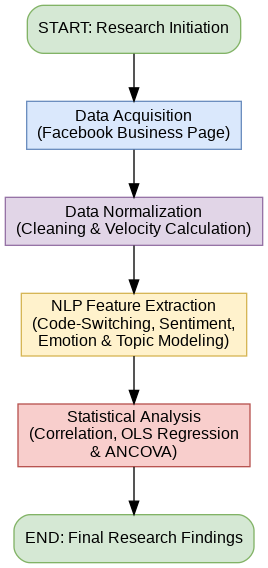

In [ ]:
import graphviz
from IPython.display import Image, display

# --- SIMPLIFIED VERTICAL RESEARCH WORKFLOW ---
dot = graphviz.Digraph('Simplified_Vertical_Workflow', comment='Vertical Research Path')
dot.attr(rankdir='TB', size='8')
dot.attr('node', fontname='Helvetica', fontsize='12')

# Terminal Nodes (Start/End)
dot.attr('node', shape='box', style='rounded,filled', fillcolor='#D5E8D4', color='#82B366')
dot.node('Start', 'START: Research Initiation')
dot.node('End', 'END: Final Research Findings')

# Process Nodes
dot.attr('node', shape='rectangle', style='filled')

# 1. Acquisition
dot.node('A', 'Data Acquisition\n(Facebook Business Page)', fillcolor='#DAE8FC', color='#6C8EBF')

# 2. Pre-processing
dot.node('B', 'Data Normalization\n(Cleaning & Velocity Calculation)', fillcolor='#E1D5E7', color='#9673A6')

# 3. NLP Pillar
dot.node('C', 'NLP Feature Extraction\n(Code-Switching, Sentiment,\nEmotion & Topic Modeling)', fillcolor='#FFF2CC', color='#D6B656')

# 4. Stats Pillar
dot.node('D', 'Statistical Analysis\n(Correlation, OLS Regression\n& ANCOVA)', fillcolor='#F8CECC', color='#B85450')

# Vertical Connections
dot.edge('Start', 'A')
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'End')

# Render and Display
dot.render('vertical_flowchart', format='png', cleanup=True)
display(Image(filename='vertical_flowchart.png'))

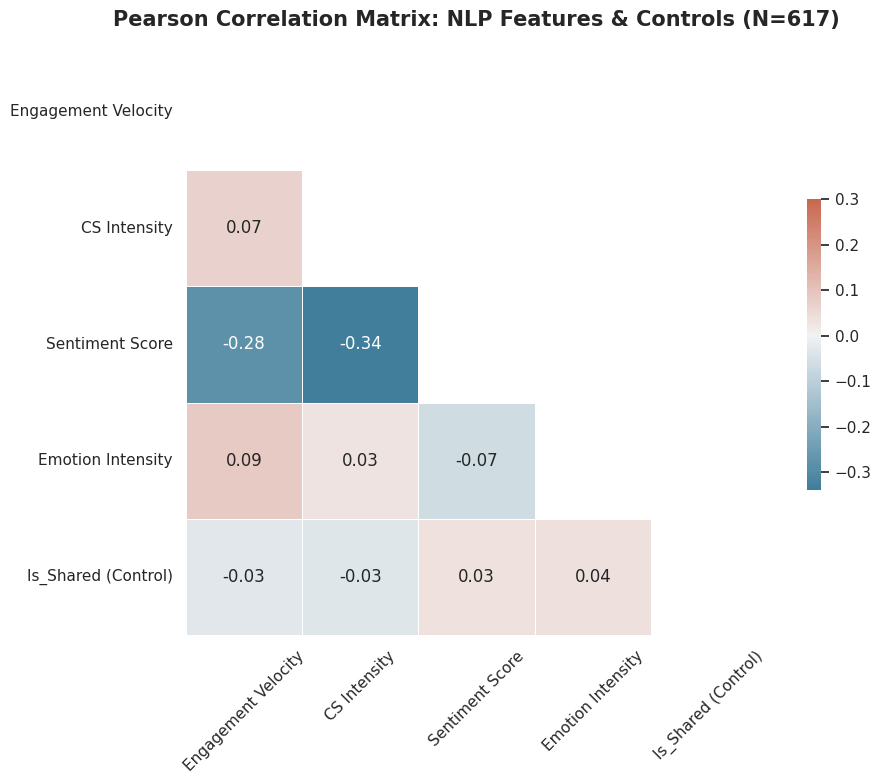

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. SELECT FINAL VARIABLES (Including Shared Control)
corr_cols = [
    'Relative Engagement (Time-Normalized)',
    'Code Switching Level (1-4)',
    'Sentiment Probability',
    'Emotion Probability',
    'Is_Shared'
]

# Create a clean dataframe for plotting
plot_df = final_table[corr_cols].copy()

# Rename for clean axis labels in the research
plot_df.columns = [
    'Engagement Velocity',
    'CS Intensity',
    'Sentiment Score',
    'Emotion Intensity',
    'Is_Shared (Control)'
]

current_corr_matrix = plot_df.corr()

# 2. VISUAL STYLE
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# 3. CREATING THE HEATMAP
# Use a mask so we don't show the same data twice
mask = np.triu(np.ones_like(current_corr_matrix, dtype=bool))
# 'RdBu_r' is a classic academic choice for correlation (Red=Pos, Blue=Neg)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(current_corr_matrix, mask=mask, cmap=cmap, vmax=.3, center=0,
            annot=True, fmt=".2f", square=True, linewidths=.5,
            cbar_kws={"shrink": .5}, annot_kws={"size": 12})



plt.title('Pearson Correlation Matrix: NLP Features & Controls (N=617)',
          fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# 4. SAVE AND DISPLAY
plt.savefig('final_correlation_heatmap.png', dpi=300)
plt.show()

<Figure size 1200x800 with 0 Axes>

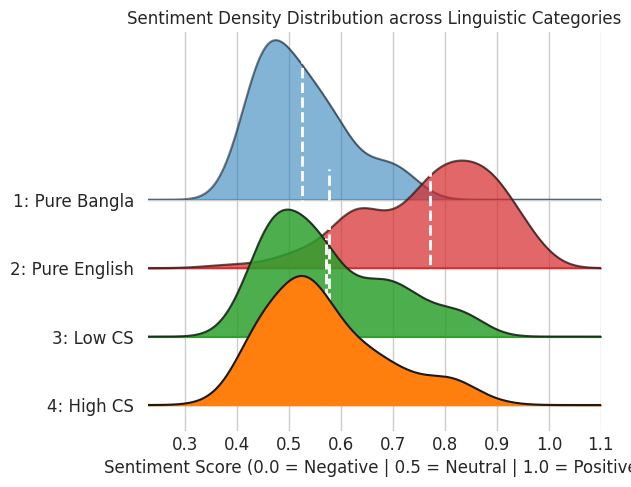

In [ ]:
# 1. INSTALL THE MISSING LIBRARY (if not already installed)
!pip install joypy -q

import matplotlib.pyplot as plt
from joypy import joyplot
import pandas as pd

# 2. CONFIGURATION - Use final_table names
column_to_plot = 'Sentiment Probability'
# Map numeric levels to labels for the Y-axis
category_map = {1: '1: Pure Bangla', 2: '2: Pure English', 3: '3: Low CS', 4: '4: High CS'}
final_table['CS_Label'] = final_table['Code Switching Level (1-4)'].map(category_map)

# Academic color palette (Muted and professional)
research_colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']

# 3. GENERATE THE RIDGE PLOT (Joyplot)
plt.figure(figsize=(12, 8))
# Note: 'by' uses the new CS_Label to ensure readable axis labels
fig, axes = joyplot(final_table,
                    column=column_to_plot,
                    by='CS_Label',
                    color=research_colors,
                    alpha=0.8,
                    fade=True,
                    overlap=1.5,
                    title="Sentiment Density Distribution across Linguistic Categories",
                    grid=True)

# 4. ADD MEAN MARKERS
# We calculate the mean for each group to show the 'center of gravity'
group_means = final_table.groupby('CS_Label')[column_to_plot].mean()

# Iterate through axes to plot the mean vertical lines
for i, ax in enumerate(axes[:-1]):
    # Extract the label for the current ridge
    label = ax.get_yticklabels()[0].get_text()
    if label in group_means:
        ax.axvline(group_means[label], color='white', linestyle='--', linewidth=2, label='Mean')



plt.xlabel("Sentiment Score (0.0 = Negative | 0.5 = Neutral | 1.0 = Positive)", fontsize=12)
plt.show()

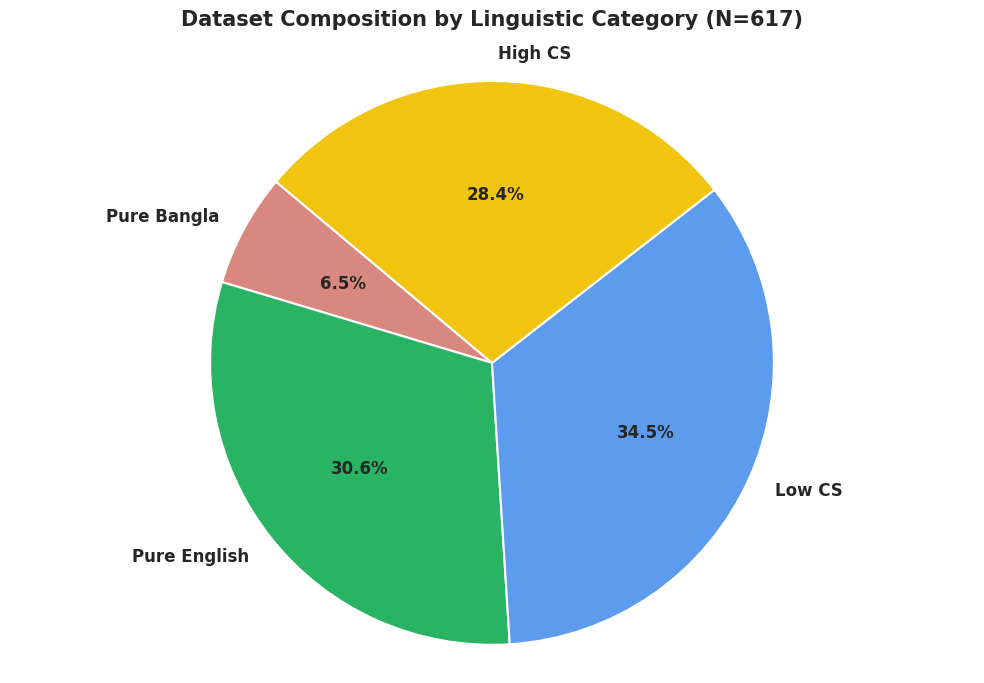

✅ Classic Pie Chart Updated: Total Sample Size N = 617


In [ ]:
import matplotlib.pyplot as plt

# 1. DATA EXTRACTION FROM final_table (N=617)
category_map = {1: 'Pure Bangla', 2: 'Pure English', 3: 'Low CS', 4: 'High CS'}
counts = final_table['Code Switching Level (1-4)'].value_counts().sort_index()

labels = [category_map[i] for i in counts.index]
sizes = counts.values

# Updated Palette: Pure Bangla=Pink, Pure English=Green, Low CS=Light Blue, High CS=Yellow
# Green updated to #28B463
colors = ["#D98880", "#28B463", "#5D9CEC", "#F1C40F"]

# 2. CREATE THE FIGURE
plt.figure(figsize=(10, 7), facecolor='white')

# 3. PLOTTING THE CLASSIC PIE
plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 12, 'fontweight': 'bold'})

# 4. FORMATTING
plt.title(f'Dataset Composition by Linguistic Category (N={sum(sizes)})',
          fontsize=15, fontweight='bold', pad=20)
plt.axis('equal')

plt.tight_layout()
plt.savefig('dataset_composition_pie_final_v2.png', dpi=300)
plt.show()

print(f"✅ Classic Pie Chart Updated: Total Sample Size N = {sum(sizes)}")

In [ ]:
from google.colab import drive
import os
import joblib

# 1. Mount to Google Drive
drive.mount('/content/drive')

# 2. Path Setup
path = '/content/drive/My Drive/Thesis_NLP_Analysis'
if not os.path.exists(path):
    os.makedirs(path)

# 3. Save the FINAL Table (N=617)
final_table.to_csv(f'{path}/Final_Thesis_Dataset_N617.csv', index=False)
final_table.to_excel(f'{path}/Final_Thesis_Dataset_N617.xlsx', index=False)

# 4. Save the Model Objects
# Saving both OLS and ANCOVA for the defense
joblib.dump(model_ols, f'{path}/ols_multivariate_model.pkl')
joblib.dump(model_ancova, f'{path}/ancova_model.pkl')

# 5. Save Summary Tables as Text Files
# OLS Summary
with open(f'{path}/ols_regression_summary.txt', 'w') as f:
    f.write(model_ols.summary().as_text())

# ANCOVA Table (including Eta-Squared)
with open(f'{path}/ancova_results_table.txt', 'w') as f:
    f.write(aov_table.to_string())

print(f"✅ All Final Assets (CSV, Excel, OLS, ANCOVA) saved at: {path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All Final Assets (CSV, Excel, OLS, ANCOVA) saved at: /content/drive/My Drive/Thesis_NLP_Analysis
